# Tester_branch에서 성능 확인 진행

In [91]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeClassifier
# Xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, plot_tree

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
# 평가지표
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
wine = load_wine()

''' 데이터 코드를 작성해주세요 '''

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

' 데이터 코드를 작성해주세요 '

In [61]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

In [62]:
# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

''' 해당 부분은 직접 작성 바랍니다 '''
df = pd.DataFrame(data=wine.data, columns= wine.feature_names)
df['target'] = wine.target

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [4]:
# HyperParameter Tunnung
# GridSearch를 HyperParmeter를 범위를 한정

param_grid = {
    "criterion" : ['gini', 'entropy'],
    "max_depth" : [2,5],
    "min_samples_split": [2,5,10],
    "min_samples_leaf" : [1,2,4]
}

Best Hyper-parameter {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Score 0.9224137931034484


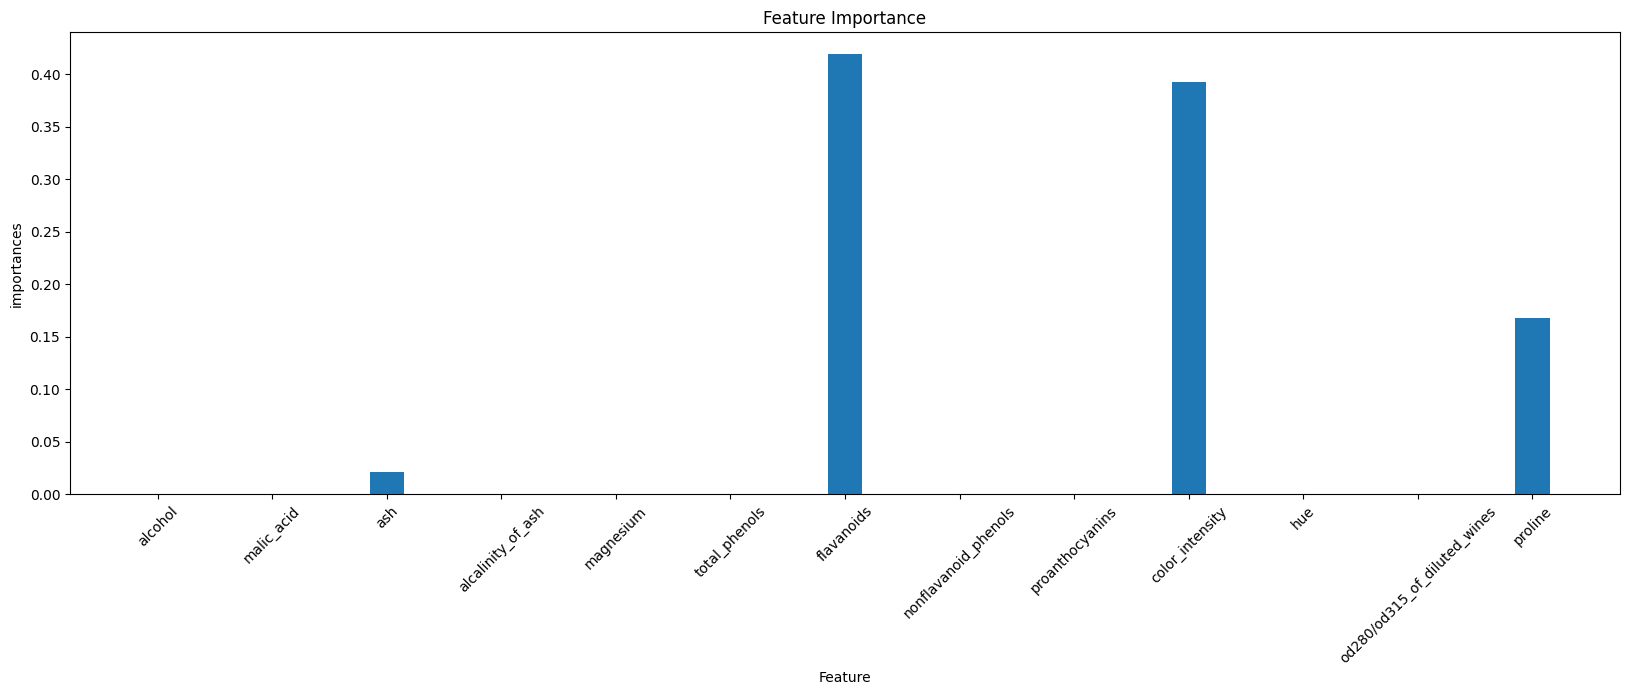

In [63]:
clf_grid = DecisionTreeClassifier(random_state= 42)
# core
grid_search = GridSearchCV(clf_grid, param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best Hyper-parameter", grid_search.best_params_)
print("Best Score", grid_search.best_score_)


# HPO만들어진 모형의 정확도 계산 
best_model = grid_search.best_estimator_

y_pred_grid = best_model.predict(X_test)
accuracy_grid = accuracy_score(y_test, y_pred_grid)



# Feature Importance를 계산
importances = best_model.feature_importances_

plt.figure(figsize = (20,6))
# 막대 그래프 생성
plt.bar(range(len(importances)), importances, width=0.3)
plt.xlabel('Feature')
plt.ylabel('importances')
plt.title('Feature Importance')
plt.xticks(range(len(importances)), X.columns, rotation = 45)
plt.show()

# DT 모델링 성능

In [ ]:
''' 코드를 작성해주세요 '''

<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

In [ ]:
''' 코드를 작성해주세요 '''

<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

In [102]:
# 하이퍼파라미터 범위지정

params = {
    "max_depth" : [3, 5, 7, 9, 15],
    "learning_rate" : [0.1, 0.01, 0.001],
    "n_estimators": [50, 100, 200, 300]
}

In [103]:
# 레이블링 인코딩

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [104]:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best accuracy: 0.9576354679802955


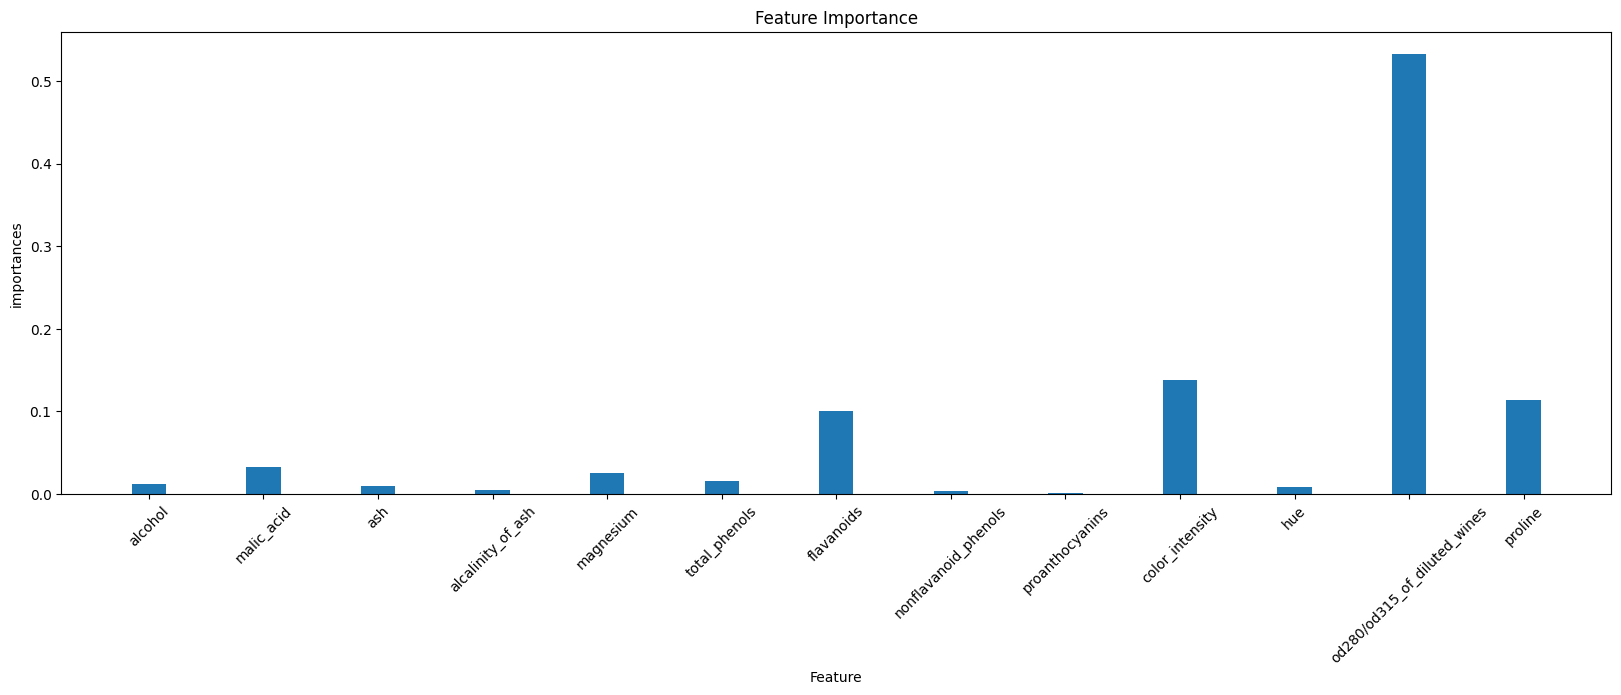

In [105]:

## 최적의 하이퍼파라미터의 학습

best_model = grid_search.best_estimator_
# 예측 및 레이블 디코딩

rf_y_pred_encoded = xgb_model.predict(X_test)
y_pred = label_encoder.inverse_transform(rf_y_pred_encoded)


# 하이퍼파라미터 최적화 
grid_search = GridSearchCV(estimator=xgb_model, param_grid=params, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train_encoded)


print("Best parameters:", grid_search.best_params_)
print("Best accuracy:" , grid_search.best_score_)

# Feature Importance를 계산
importances = best_model.feature_importances_

plt.figure(figsize = (20,6))
# 막대 그래프 생성
plt.bar(range(len(importances)), importances, width=0.3)
plt.xlabel('Feature')
plt.ylabel('importances')
plt.title('Feature Importance')
plt.xticks(range(len(importances)), X.columns, rotation = 45)
plt.show()

# 성능 비교 시각화

In [ ]:
''' 코드를 작성해주세요 '''

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">

DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



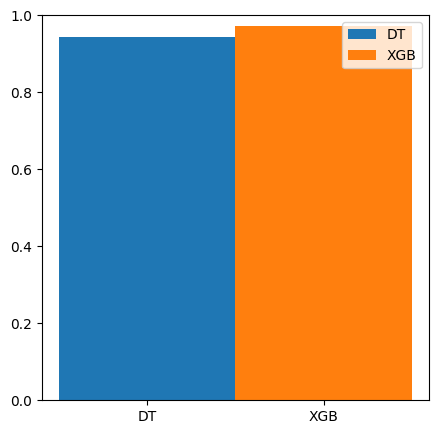

In [111]:




# Decision Tree 모델 학습 및 평가
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print(f"DT accuracy : {dt_acc}")
print(classification_report(y_test, dt_pred))




# XGBoost 모델 학습 및 평가


xgb =  GridSearchCV(estimator=xgb_model, param_grid=params, cv=5, scoring='accuracy', n_jobs=-1)
xgb.fit(X_train, y_train_encoded)

rf_y_pred_encoded = xgb.predict(X_test)
y_pred = label_encoder.inverse_transform(rf_y_pred_encoded)


xgb_acc = accuracy_score(y_test, rf_y_pred_encoded)
print(f"XGB accuracy : {xgb_acc}")
print(classification_report(y_test,rf_y_pred_encoded ))

# 성능 비교 

w = 1
plt.figure(figsize=(5,5))
plt.bar('DT', dt_acc,width=w)
plt.bar('XGB',  xgb_acc, width=w)

plt.ylim(0, 1)
plt.legend(['DT','XGB'])
plt.show()
